# Smart Loan Recovery System

## Business Objective

A financial institution offers different types of loans but is currently facing difficulties in recovering them. There has been a noticeable increase in delinquent loans, especially from borrowers who have missed multiple payments.

The management aims to improve the loan recovery process by identifying the most effective strategies. This will be done by analyzing borrower profiles, outstanding loan amounts, and past recovery results.

Using historical data, the goal is to build a **Loan Recovery Strategy Model** that can predict the best recovery method for each delinquent borrower. This model will help maximize loan recovery while minimizing operational costs.

## Problems to Solve:

1. Group customers based on details like loan amount, income, payment history, and missed payments.

2. Find the best way to collect money (like calls, settlement offers, legal action, or agents).

3. Get maximum money back while spending minimum cost.

4. Create a system that can identify customers early who are likely to stop paying (high risk).

## Step 1: Import Required Libraries

In [3]:
# Import required libraries (basic libraries only)
import pandas as pd          # Data manipulation and analysis
import numpy as np           # Numerical analysis
import matplotlib.pyplot as plt  # For all plots and charts
import seaborn as sns        # For statistical visualizations
import pickle                # For saving/loading models
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Load and Explore the Dataset

In [4]:
# Load the CSV data file using pandas:
df = pd.read_csv("../dataset/loan-recovery.csv")    # Loaded and stored in variable df

# Preview the data:
df.head(5)                               # Displays first 5 rows of the data

,Borrower_ID,Age,Gender,Employment_Type,Monthly_Income,Num_Dependents,Loan_ID,Loan_Amount,Loan_Tenure,Interest_Rate,...,Collateral_Value,Outstanding_Loan_Amount,Monthly_EMI,Payment_History,Num_Missed_Payments,Days_Past_Due,Recovery_Status,Collection_Attempts,Collection_Method,Legal_Action_Taken
0,BRW_1,59,Male,Salaried,215422,0,LN_1,1445796,60,12.39,...,1.727997e+06,2.914130e+05,4856.88,On-Time,0,0,Partially Recovered,1,Settlement Offer,No
1,BRW_2,49,Female,Salaried,60893,0,LN_2,1044620,12,13.47,...,1.180032e+06,6.652042e+05,55433.68,On-Time,0,0,Fully Recovered,2,Settlement Offer,No
2,BRW_3,35,Male,Salaried,116520,1,LN_3,1923410,72,7.74,...,2.622540e+06,1.031372e+06,14324.61,Delayed,2,124,Fully Recovered,2,Legal Notice,No
3,BRW_4,63,Female,Salaried,140818,2,LN_4,1811663,36,12.23,...,1.145493e+06,2.249739e+05,6249.28,On-Time,1,56,Fully Recovered,2,Calls,No
4,BRW_5,28,Male,Salaried,76272,1,LN_5,88578,48,16.13,...,0.000000e+00,3.918989e+04,816.46,On-Time,1,69,Fully Recovered,0,Debt Collectors,No


In [5]:
# Shape and Structure of the data:
structure = df.shape                     # Matrix rows x columns
print(f'Structure of the data:\n{structure}')

Structure of the data:
(500, 21)


In [6]:
# Check information on the data:
df.info()                                # Provides info on columns, dtypes and null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Borrower_ID              500 non-null    object 
 1   Age                      500 non-null    int64  
 2   Gender                   500 non-null    object 
 3   Employment_Type          500 non-null    object 
 4   Monthly_Income           500 non-null    int64  
 5   Num_Dependents           500 non-null    int64  
 6   Loan_ID                  500 non-null    object 
 7   Loan_Amount              500 non-null    int64  
 8   Loan_Tenure              500 non-null    int64  
 9   Interest_Rate            500 non-null    float64
 10  Loan_Type                500 non-null    object 
 11  Collateral_Value         500 non-null    float64
 12  Outstanding_Loan_Amount  500 non-null    float64
 13  Monthly_EMI              500 non-null    float64
 14  Payment_History          5

The information shows there are **no missing values** out of the whole 500 rows. Also, the datatypes of the columns are correct.

In [7]:
# Check for duplicate rows:
duplicate_rows = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicate_rows}')

Number of duplicate rows: 0


In [8]:
# Descriptive Statistics:
stats = df.describe()
stats.round(2).T

,count,mean,std,min,25%,50%,75%,max
Age,500.0,43.12,12.73,21.00,32.00,44.00,53.00,64.00
Monthly_Income,500.0,134829.92,68969.36,15207.00,76343.25,134929.50,193086.25,249746.00
Num_Dependents,500.0,1.48,1.15,0.00,0.00,1.00,3.00,3.00
Loan_Amount,500.0,1024907.03,590755.60,54138.00,462984.75,997124.00,1557952.25,1995325.00
Loan_Tenure,500.0,46.10,18.24,12.00,36.00,48.00,60.00,72.00
Interest_Rate,500.0,11.19,3.78,5.02,7.91,10.92,14.58,17.97
Collateral_Value,500.0,603224.02,745713.07,0.00,0.00,232768.40,1111106.06,2744395.14
Outstanding_Loan_Amount,500.0,562725.98,472358.06,15712.83,182207.20,413323.97,832478.70,1932395.92
Monthly_EMI,500.0,15861.54,18709.23,261.88,4039.10,9330.17,20439.48,127849.23
Num_Missed_Payments,500.0,1.91,2.11,0.00,1.00,2.00,3.00,12.00


### Data Insights:

- **Age:** Customers are between 21 and 64 years old. Average age is around 43, so most borrowers are middle-aged working people.
- **Monthly Income:** Average income is about ₹1.35 lakh. Some earn very low (₹15K), while some earn up to ₹2.5 lakh, showing big income differences.
- **Dependents:** On average, customers have 1–2 dependents.
- **Loan Amount:** Ranges from ₹54K to ₹20 lakh, with an average of about ₹10 lakh.
- **Loan Tenure:** From 1 to 6 years, with an average of about 4 years.
- **Interest Rate:** Ranges from 5% to nearly 18%, average of 11.19%.
- **Collateral Value:** Some loans have no collateral (₹0), many are unsecured loans.
- **Outstanding Loan Amount:** Average pending loan is about ₹5.6 lakh.
- **Missed Payments:** On average, customers miss around 2 payments (max: 12).
- **Days Past Due:** Average delay is about 70 days (max: 180 days).

## Step 3: Exploratory Data Analysis (EDA)

### 3.1 Distribution of Loan Amounts

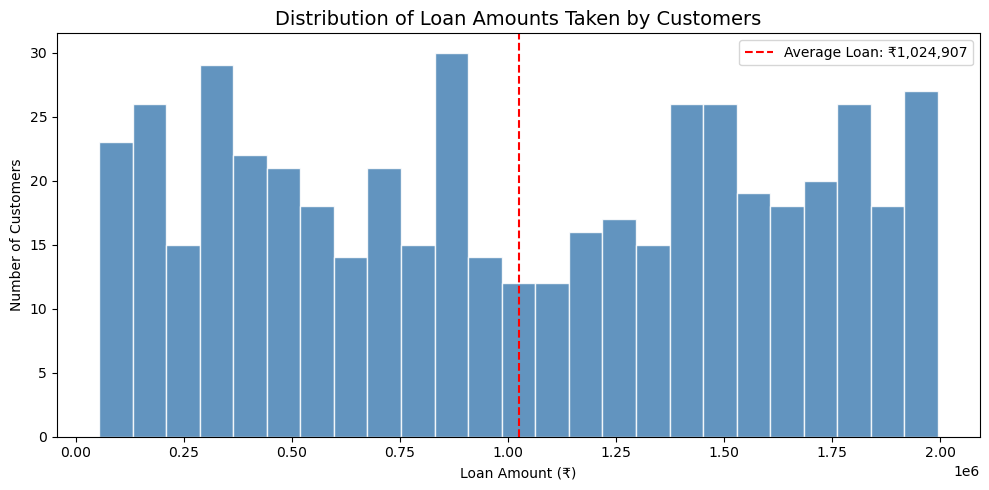

In [9]:
# Distribution of Loan Amounts taken by Customers
plt.figure(figsize=(10, 5))
plt.hist(df['Loan_Amount'], bins=25, color='steelblue', edgecolor='white', alpha=0.85)

# Add average line
mean_val = df['Loan_Amount'].mean()
plt.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Average Loan: ₹{mean_val:,.0f}')

plt.title('Distribution of Loan Amounts Taken by Customers', fontsize=14)
plt.xlabel('Loan Amount (₹)')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()

### Insights:
- Loan amounts are distributed across a wide range, from low to high values.
- Most customers fall in the mid-range loan segment.
- The red dashed line represents the average loan amount (₹10.25 lakh).
- The distribution appears relatively balanced, suggesting diverse customer segments.

### 3.2 Loan Amount vs Monthly Income with Risk Identification

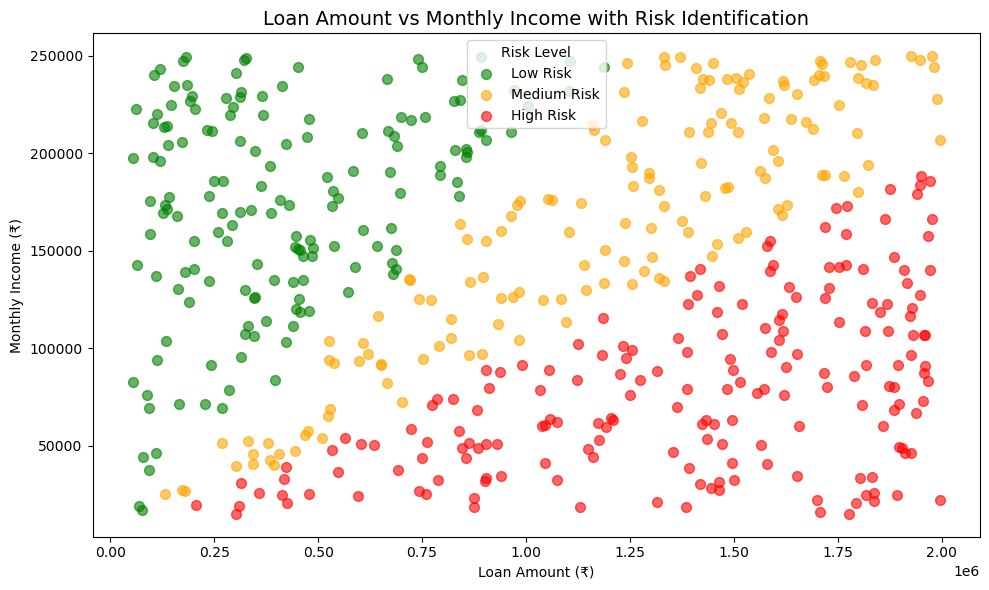


Average Loan Amount: 1,024,907.03
Average Monthly Income: 134,829.92


In [10]:
# Create Risk Category based on Loan-to-Income ratio
def risk_category(row):
    ratio = row['Loan_Amount'] / row['Monthly_Income']
    if ratio < 5:
        return 'Low Risk'
    elif ratio < 10:
        return 'Medium Risk'
    else:
        return 'High Risk'

# Apply function to dataframe
df['Risk_Level'] = df.apply(risk_category, axis=1)

# Scatter plot
plt.figure(figsize=(10, 6))
colors = {'Low Risk': 'green', 'Medium Risk': 'orange', 'High Risk': 'red'}

for level, color in colors.items():
    mask = df['Risk_Level'] == level
    plt.scatter(df.loc[mask, 'Loan_Amount'], df.loc[mask, 'Monthly_Income'],
                c=color, label=level, alpha=0.6, s=50)

plt.title('Loan Amount vs Monthly Income with Risk Identification', fontsize=14)
plt.xlabel('Loan Amount (₹)')
plt.ylabel('Monthly Income (₹)')
plt.legend(title='Risk Level')
plt.tight_layout()
plt.show()

print(f"\nAverage Loan Amount: {df['Loan_Amount'].mean():,.2f}")
print(f"Average Monthly Income: {df['Monthly_Income'].mean():,.2f}")

### Insights:
- Customers with high income and moderate loan amounts are classified as **low risk**.
- Individuals with low income but high loan amounts fall under **high risk**.
- Risk increases when loan size is not supported by income level.

### 3.3 Payment History vs Loan Recovery Status

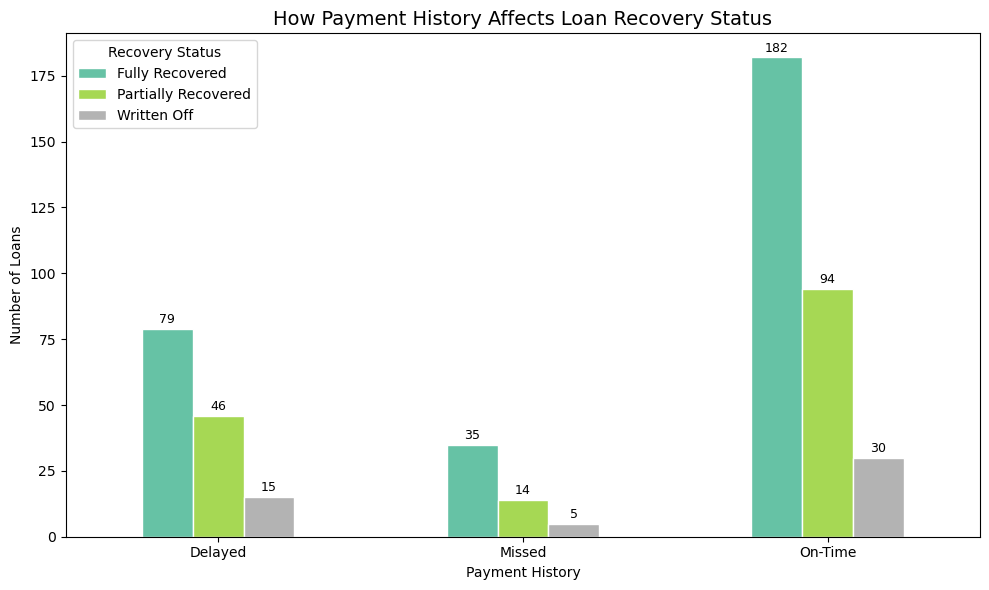

In [11]:
# Grouped bar chart: Payment History vs Recovery Status
cross_tab = pd.crosstab(df['Payment_History'], df['Recovery_Status'])

cross_tab.plot(kind='bar', figsize=(10, 6), colormap='Set2', edgecolor='white')

plt.title('How Payment History Affects Loan Recovery Status', fontsize=14)
plt.xlabel('Payment History')
plt.ylabel('Number of Loans')
plt.xticks(rotation=0)
plt.legend(title='Recovery Status')

# Add value labels on bars
for container in plt.gca().containers:
    plt.gca().bar_label(container, padding=2, fontsize=9)

plt.tight_layout()
plt.show()

### Insights:
- Loans with **on-time payments** are mostly fully recovered.
- **Delayed payments** result in a mix of partial and full recoveries, with some written off.
- **Missed payments** have a significantly lower recovery rate.

### 3.4 Missed Payments vs Recovery Status (Box Plot)

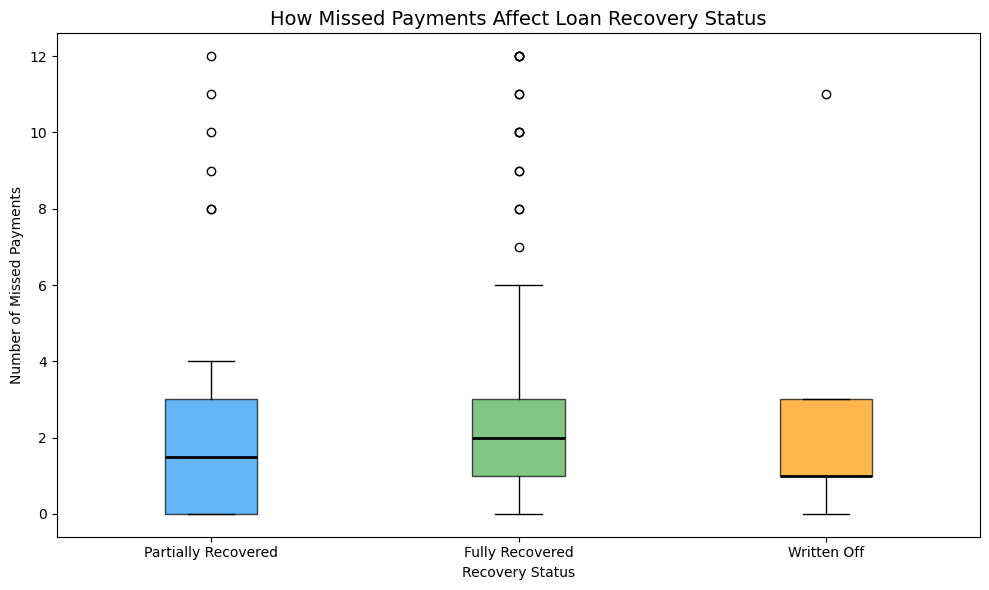

In [12]:
# Box plot: Missed Payments across Recovery Status
plt.figure(figsize=(10, 6))

recovery_groups = [df[df['Recovery_Status'] == status]['Num_Missed_Payments'].values
                   for status in df['Recovery_Status'].unique()]
labels = df['Recovery_Status'].unique()

bp = plt.boxplot(recovery_groups, labels=labels, patch_artist=True,
                 medianprops=dict(color='black', linewidth=2))

# Color each box
colors_box = ['#2196F3', '#4CAF50', '#FF9800']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title('How Missed Payments Affect Loan Recovery Status', fontsize=14)
plt.xlabel('Recovery Status')
plt.ylabel('Number of Missed Payments')
plt.tight_layout()
plt.show()

### Insights:
- **Fully recovered** loans have a median of ~2 missed payments — recovery is possible with timely intervention.
- **Partially recovered** has more variation — can segment as at-risk borrowers.
- **Written off** median is similar, suggesting wrong borrower profiling or lack of follow-ups.

### 3.5 Monthly Income vs Loan Amount by Recovery Status

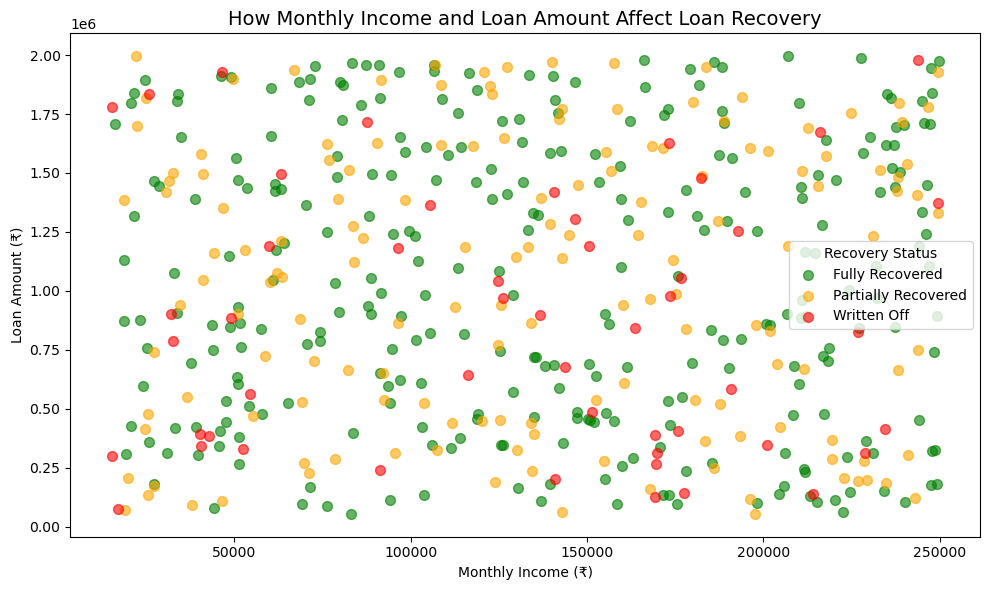

In [13]:
# Scatter plot: Monthly Income vs Loan Amount by Recovery Status
plt.figure(figsize=(10, 6))

recovery_colors = {
    'Fully Recovered': 'green',
    'Partially Recovered': 'orange',
    'Written Off': 'red'
}

for status, color in recovery_colors.items():
    mask = df['Recovery_Status'] == status
    plt.scatter(df.loc[mask, 'Monthly_Income'], df.loc[mask, 'Loan_Amount'],
                c=color, label=status, alpha=0.6, s=50)

plt.title('How Monthly Income and Loan Amount Affect Loan Recovery', fontsize=14)
plt.xlabel('Monthly Income (₹)')
plt.ylabel('Loan Amount (₹)')
plt.legend(title='Recovery Status')
plt.tight_layout()
plt.show()

### Insights:
- High income borrowers tend to have better recovery odds.
- Low income borrowers show higher rates of Written-Off or Partially Recovered loans.
- Strong monthly income acts as a cushion to prevent defaults.

## Step 4: Feature Engineering

Engineering new features based on existing ones to improve model performance.

In [14]:
# Engineering new features onto a copy of this dataset:
df_1 = df.copy()

# 1. EMI to Income Ratio:
#    - Measures the repayment burden of a borrower
#    - If ratio > 0.4, the borrower is in a debt stress zone
df_1['EMI_to_Income_Ratio'] = df_1['Monthly_EMI'] / df_1['Monthly_Income']

# 2. Collateral Coverage:
#    - Measures how well the loan is secured by collateral
#    - If < 1: collateral is less than loan amount (higher risk)
#    - If > 1: safe zone, lender can recover money even on default
df_1['Collateral_Coverage'] = df_1['Collateral_Value'] / df_1['Loan_Amount']

# 3. Default Severity:
#    - A custom metric quantifying how bad the default is
#    - Combines frequency and extent of delay
df_1['Default_Severity'] = df_1['Num_Missed_Payments'] * df_1['Days_Past_Due']

print("New features created:")
print(df_1[['EMI_to_Income_Ratio', 'Collateral_Coverage', 'Default_Severity']].describe().round(3))

New features created:
       EMI_to_Income_Ratio  Collateral_Coverage  Default_Severity
count              500.000              500.000           500.000
mean                 0.191                0.569           178.732
std                  0.387                0.547           235.708
min                  0.001                0.000             0.000
25%                  0.030                0.000             6.750
50%                  0.084                0.617           110.500
75%                  0.194                1.072           246.500
max                  5.101                1.495          1632.000


In [15]:
# Example: Filter high-risk borrowers using engineered features
high_risk_filter = df_1[
    (df_1['EMI_to_Income_Ratio'] > 0.5) &      # Moderate to high loan burden
    (df_1['Collateral_Coverage'] < 1) &         # Collateral not enough to cover loan
    (df_1['Default_Severity'] > 250)            # Multiple missed payments + large delays
]
print(f"High-risk borrowers identified: {len(high_risk_filter)}")
high_risk_filter.head()

High-risk borrowers identified: 8


,Borrower_ID,Age,Gender,Employment_Type,Monthly_Income,Num_Dependents,Loan_ID,Loan_Amount,Loan_Tenure,Interest_Rate,...,Num_Missed_Payments,Days_Past_Due,Recovery_Status,Collection_Attempts,Collection_Method,Legal_Action_Taken,Risk_Level,EMI_to_Income_Ratio,Collateral_Coverage,Default_Severity
28,BRW_29,45,Female,Salaried,152348,1,LN_29,1581064,12,9.42,...,2,144,Fully Recovered,2,Debt Collectors,No,High Risk,0.632001,0.563130,288
90,BRW_91,44,Female,Salaried,21570,1,LN_91,1838380,72,9.62,...,3,94,Fully Recovered,3,Settlement Offer,No,High Risk,0.984666,0.000000,282
104,BRW_105,61,Female,Salaried,150542,2,LN_105,1190844,12,15.14,...,3,147,Written Off,10,Legal Notice,No,Medium Risk,0.562147,0.000000,441
148,BRW_149,49,Male,Salaried,20704,3,LN_149,426047,12,12.35,...,12,92,Fully Recovered,2,Calls,No,High Risk,1.704440,0.000000,1104
179,BRW_180,57,Female,Salaried,18726,0,LN_180,873759,72,5.61,...,3,145,Fully Recovered,3,Calls,No,High Risk,0.561126,0.928155,435


## Step 5: Correlation Heatmap

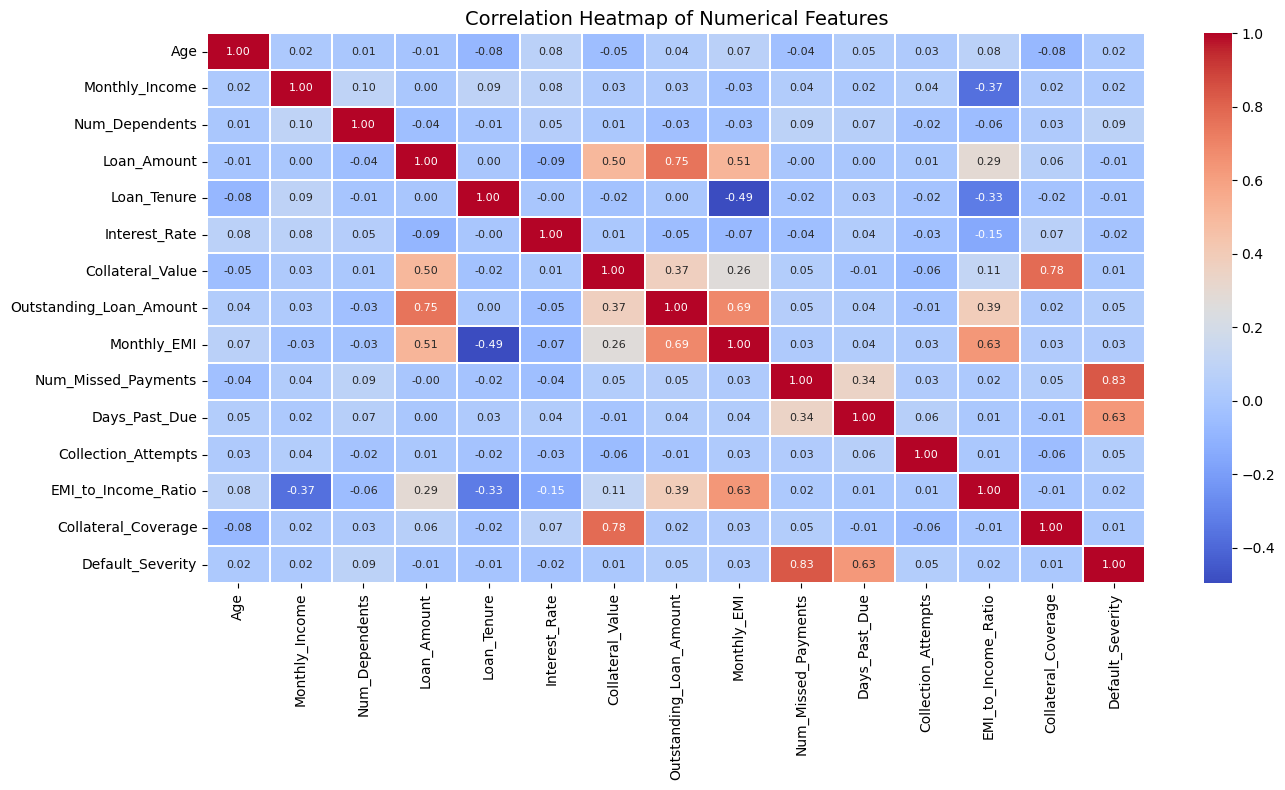

In [16]:
# Correlation heatmap for numerical features
df_1_corr = df_1.select_dtypes(include='number').corr()

plt.figure(figsize=(14, 8))
sns.heatmap(df_1_corr,
            cmap='coolwarm',
            annot=True,
            fmt='.2f',
            linewidths=0.3,
            annot_kws={'size': 8})
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

### Key Insights:
- **Loan Amount & Outstanding Loan Amount** → 0.75 (Naturally expected)
- **Num Missed Payments & Default Severity** → 0.83 (More missed payments = greater default severity)
- **Loan Tenure & Monthly EMI** → -0.49 (Longer tenures reduce monthly EMI)

## Step 6: Select Final Features

In [17]:
# Define the features:
features = [
    'Age',
    'Monthly_Income',
    'Num_Dependents',
    'Loan_Tenure',
    'Interest_Rate',
    'Outstanding_Loan_Amount',
    'Collection_Attempts',
    'EMI_to_Income_Ratio',
    'Collateral_Coverage',
    'Default_Severity'
]

# Finalize the data:
df_1 = df_1[features]

# Preview the data:
print(f"Final feature dataset shape: {df_1.shape}")
df_1.head(5)

Final feature dataset shape: (500, 10)


,Age,Monthly_Income,Num_Dependents,Loan_Tenure,Interest_Rate,Outstanding_Loan_Amount,Collection_Attempts,EMI_to_Income_Ratio,Collateral_Coverage,Default_Severity
0,59,215422,0,60,12.39,2.914130e+05,1,0.022546,1.195187,0
1,49,60893,0,12,13.47,6.652042e+05,2,0.910346,1.129628,0
2,35,116520,1,72,7.74,1.031372e+06,2,0.122937,1.363485,248
3,63,140818,2,36,12.23,2.249739e+05,2,0.044378,0.632288,56
4,28,76272,1,48,16.13,3.918989e+04,0,0.010705,0.000000,69


## Step 7: K-Means Clustering — Borrower Segmentation

In [18]:
# Import sklearn modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Split dataset into training and testing sets (70/30 split)
train_data, test_data = train_test_split(
    df_1,
    test_size=0.3,
    random_state=42
)

print(f"Training data: {train_data.shape}")
print(f"Testing data:  {test_data.shape}")

Training data: (350, 10)
Testing data:  (150, 10)


In [19]:
# Scale features using StandardScaler
scaler = StandardScaler()

# Fit on training data and transform
train_scaled = scaler.fit_transform(train_data[features])

# Transform test data using same scaler
test_scaled = scaler.transform(test_data[features])

print("Features scaled successfully!")

Features scaled successfully!


In [20]:
# Apply KMeans Clustering on Train Data
kmeans = KMeans(
    n_clusters=4,       # 4 borrower segments
    random_state=42,
    n_init=10
)

# Fit and assign cluster labels to training data
train_data = train_data.copy()
train_data['Borrower_Segment'] = kmeans.fit_predict(train_scaled)

# Predict cluster labels for test data
test_data = test_data.copy()
test_data['Borrower_Segment'] = kmeans.predict(test_scaled)

print("KMeans clustering applied!")
print("Cluster distribution (Train):")
print(train_data['Borrower_Segment'].value_counts().sort_index())

KMeans clustering applied!
Cluster distribution (Train):
Borrower_Segment
0     40
1    136
2     43
3    131
Name: count, dtype: int64


In [21]:
# Analyze cluster characteristics to assign meaningful names
segmented = train_data.groupby('Borrower_Segment')[features].mean().round(2)
print("Cluster Averages:")
print(segmented)

Cluster Averages:
                    Age  Monthly_Income  Num_Dependents  Loan_Tenure  \
Borrower_Segment                                                       
0                 47.08        73250.20            1.18        22.80   
1                 46.24       145431.68            1.29        52.68   
2                 42.91       138904.09            1.70        48.00   
3                 39.42       145315.12            1.55        44.61   

                  Interest_Rate  Outstanding_Loan_Amount  Collection_Attempts  \
Borrower_Segment                                                                
0                          9.53                935528.04                 2.92   
1                         10.90                485979.66                 2.87   
2                         10.29                913970.65                 3.28   
3                         11.72                414979.42                 2.79   

                  EMI_to_Income_Ratio  Collateral_Coverage  De

In [22]:
# Map cluster numbers to human-readable segment names
segment_mapping = {
    0: 'Low Income, High EMI Burden Borrowers',
    1: 'Affluent, Low Risk Borrowers',
    2: 'High Income, High Default Risk Borrowers',
    3: 'Secured, Moderate Risk Borrowers'
}

# Apply mapping to both datasets
train_data['Segment_Name'] = train_data['Borrower_Segment'].map(segment_mapping)
test_data['Segment_Name'] = test_data['Borrower_Segment'].map(segment_mapping)

print("Segment distribution:")
print(train_data['Segment_Name'].value_counts())

Segment distribution:
Segment_Name
Affluent, Low Risk Borrowers                136
Secured, Moderate Risk Borrowers            131
High Income, High Default Risk Borrowers     43
Low Income, High EMI Burden Borrowers        40
Name: count, dtype: int64


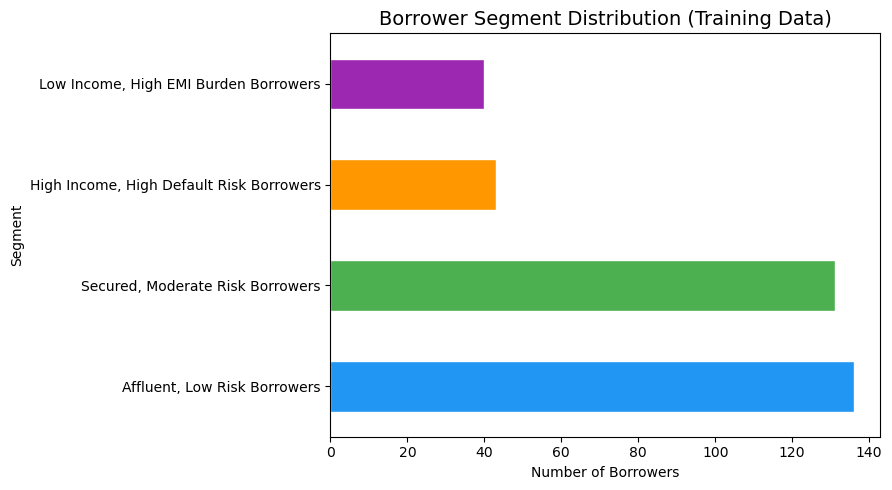

In [23]:
# Visualize borrower segments
plt.figure(figsize=(9, 5))
train_data['Segment_Name'].value_counts().plot(kind='barh', color=['#2196F3','#4CAF50','#FF9800','#9C27B0'], edgecolor='white')
plt.title('Borrower Segment Distribution (Training Data)', fontsize=14)
plt.xlabel('Number of Borrowers')
plt.ylabel('Segment')
plt.tight_layout()
plt.show()

## Step 8: Early Default Detection — High Risk Flag

In [24]:
# Define high-risk segments
high_risk_segments = [
    'Low Income, High EMI Burden Borrowers',
    'High Income, High Default Risk Borrowers'
]

# Create binary high-risk flag (1 = high risk, 0 = low/moderate risk)
train_data['High_Risk_Flag'] = train_data['Segment_Name'].apply(
    lambda x: 1 if x in high_risk_segments else 0
)
test_data['High_Risk_Flag'] = test_data['Segment_Name'].apply(
    lambda x: 1 if x in high_risk_segments else 0
)

print("High Risk Flag Distribution (Train):")
print(train_data['High_Risk_Flag'].value_counts())

High Risk Flag Distribution (Train):
High_Risk_Flag
0    267
1     83
Name: count, dtype: int64


## Step 9: Model Building — Random Forest Classifier

Using **Random Forest** (a basic sklearn model)

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Feature & target
X = train_data[features]
y = train_data['High_Risk_Flag']

# Train-validation split (Stratified for class balance)
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize Random Forest Classifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    min_samples_split=5
)

# Fit model on training data
rf.fit(X_train, y_train)

# Evaluate on validation set
y_pred = rf.predict(X_valid)
print("=== Validation Set Results ===")
print(classification_report(y_valid, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_valid, y_pred))

=== Validation Set Results ===
              precision    recall  f1-score   support

           0       0.91      0.92      0.92        53
           1       0.75      0.71      0.73        17

    accuracy                           0.87        70
   macro avg       0.83      0.82      0.82        70
weighted avg       0.87      0.87      0.87        70

Confusion Matrix:
[[49  4]
 [ 5 12]]


### Feature Importance

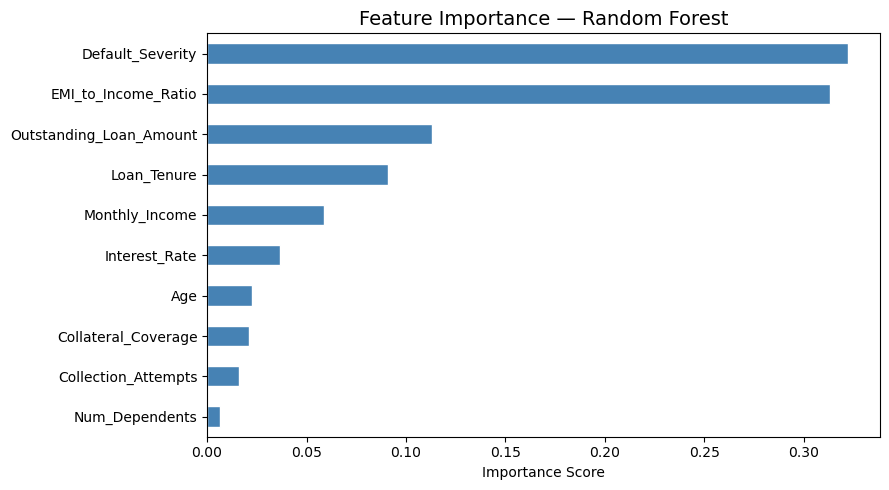

In [26]:
# Feature importance chart
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
feat_imp.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Feature Importance — Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Step 10: Evaluate Model on Test Data

In [27]:
# Predict on test data
test_data['Predicted_High_Risk'] = rf.predict(test_data[features])
test_data['Predicted_Risk_Score'] = rf.predict_proba(test_data[features])[:, 1]

# Evaluation Results
print("=== Test Set Results ===")
print("Confusion Matrix:")
print(confusion_matrix(test_data['High_Risk_Flag'], test_data['Predicted_High_Risk']))

print("\nClassification Report:")
print(classification_report(test_data['High_Risk_Flag'], test_data['Predicted_High_Risk']))

roc_score = roc_auc_score(test_data['High_Risk_Flag'], test_data['Predicted_Risk_Score'])
print(f"ROC AUC Score: {roc_score:.4f}")

=== Test Set Results ===
Confusion Matrix:
[[112   6]
 [  6  26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       118
           1       0.81      0.81      0.81        32

    accuracy                           0.92       150
   macro avg       0.88      0.88      0.88       150
weighted avg       0.92      0.92      0.92       150

ROC AUC Score: 0.9770


### ROC Curve

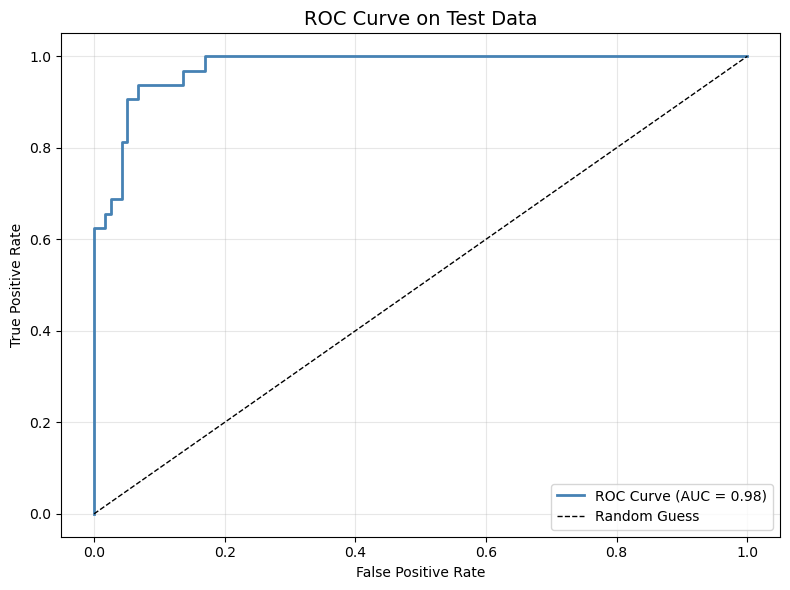

In [28]:
from sklearn.metrics import roc_curve

# Compute FPR, TPR
fpr, tpr, thresholds = roc_curve(test_data['High_Risk_Flag'], test_data['Predicted_Risk_Score'])

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2,
         label=f'ROC Curve (AUC = {roc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Data', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Business Interpretation:

The Smart Loan Recovery System can correctly flag high-risk borrowers before default with high accuracy. The ROC AUC score demonstrates the model's strong ability to discriminate between high-risk and low-risk borrowers. The system is catching problems before they happen.

## Step 11: Dynamic Recovery Strategy Based on Risk Scores

In [29]:
# Dynamic recovery strategy function based on predicted risk scores
def assign_recovery_strategy(risk_score):
    if risk_score > 0.75:
        return ("[HIGH RISK] Initiate legal proceedings with asset seizure notices, "
                "escalate to external recovery agencies, and enforce loan recovery under default clauses.")
    elif 0.50 <= risk_score <= 0.75:
        return ("[MODERATE RISK] Offer structured settlements with penal interest adjustments, "
                "negotiate revised EMI plans, and initiate soft legal notices.")
    else:
        return ("[LOW RISK] Send automated payment reminders, schedule regular financial health reviews, "
                "and maintain active borrower engagement for early warnings.")

# Apply to test data
test_data['Recovery_Strategy'] = test_data['Predicted_Risk_Score'].apply(assign_recovery_strategy)

# Preview results
print("Sample recovery strategies:")
pd.set_option('display.max_colwidth', None)
print(test_data[['Predicted_Risk_Score', 'Predicted_High_Risk', 'Recovery_Strategy']].head(5).to_string())

Sample recovery strategies:
     Predicted_Risk_Score  Predicted_High_Risk                                                                                                                                            Recovery_Strategy
361              0.295060                    0          [LOW RISK] Send automated payment reminders, schedule regular financial health reviews, and maintain active borrower engagement for early warnings.
73               0.000533                    0          [LOW RISK] Send automated payment reminders, schedule regular financial health reviews, and maintain active borrower engagement for early warnings.
374              0.000625                    0          [LOW RISK] Send automated payment reminders, schedule regular financial health reviews, and maintain active borrower engagement for early warnings.
155              0.848920                    1  [HIGH RISK] Initiate legal proceedings with asset seizure notices, escalate to external recovery agencies, a

## Step 12: Testing on Unseen Borrower Data

In [30]:
# High Risk borrower sample
high_risk_sample = pd.DataFrame([{
    'Age': 24,
    'Monthly_Income': 18000,
    'Num_Dependents': 3,
    'Loan_Tenure': 72,
    'Interest_Rate': 16.8,
    'Outstanding_Loan_Amount': 1560000,
    'Collection_Attempts': 3,
    'EMI_to_Income_Ratio': 1.125,
    'Collateral_Coverage': 0.0,
    'Default_Severity': 300
}])

# Low Risk borrower sample
low_risk_sample = pd.DataFrame([{
    'Age': 42,
    'Monthly_Income': 250000,
    'Num_Dependents': 1,
    'Loan_Tenure': 36,
    'Interest_Rate': 9.2,
    'Outstanding_Loan_Amount': 300000,
    'Collection_Attempts': 0,
    'EMI_to_Income_Ratio': 0.048,
    'Collateral_Coverage': 3.75,
    'Default_Severity': 0
}])

# Moderate Risk borrower sample
moderate_risk_sample = pd.DataFrame([{
    'Age': 35,
    'Monthly_Income': 60000,
    'Num_Dependents': 2,
    'Loan_Tenure': 48,
    'Interest_Rate': 12.0,
    'Outstanding_Loan_Amount': 500000,
    'Collection_Attempts': 2,
    'EMI_to_Income_Ratio': 0.55,
    'Collateral_Coverage': 0.8,
    'Default_Severity': 120
}])

# Get risk scores for all samples
high_risk_sample['Predicted_Risk_Score'] = rf.predict_proba(high_risk_sample[features])[:, 1]
low_risk_sample['Predicted_Risk_Score'] = rf.predict_proba(low_risk_sample[features])[:, 1]
moderate_risk_sample['Predicted_Risk_Score'] = rf.predict_proba(moderate_risk_sample[features])[:, 1]

# Assign strategies
for label, sample in [('HIGH RISK', high_risk_sample), ('MODERATE RISK', moderate_risk_sample), ('LOW RISK', low_risk_sample)]:
    score = sample['Predicted_Risk_Score'].iloc[0]
    strategy = assign_recovery_strategy(score)
    print(f"--- {label} Borrower ---")
    print(f"Risk Score: {score:.4f}")
    print(f"Strategy: {strategy}")
    print()

--- HIGH RISK Borrower ---
Risk Score: 0.5415
Strategy: [MODERATE RISK] Offer structured settlements with penal interest adjustments, negotiate revised EMI plans, and initiate soft legal notices.

--- MODERATE RISK Borrower ---
Risk Score: 0.7252
Strategy: [MODERATE RISK] Offer structured settlements with penal interest adjustments, negotiate revised EMI plans, and initiate soft legal notices.

--- LOW RISK Borrower ---
Risk Score: 0.0360
Strategy: [LOW RISK] Send automated payment reminders, schedule regular financial health reviews, and maintain active borrower engagement for early warnings.



## Step 13: Save Models and Artifacts for Deployment

In [31]:
# Save reference data (merged train + test)
reference_data = pd.concat([train_data, test_data], ignore_index=True)
reference_data.to_pickle("reference_data.pkl")
reference_data.to_csv("reference_data.csv", index=False)
print(f"Reference data saved: {reference_data.shape}")

Reference data saved: (500, 16)


In [32]:
# Save the trained Random Forest model
with open('randomforest_tuned.pkl', 'wb') as f:
    pickle.dump(rf, f)
print("Random Forest model saved as randomforest_tuned.pkl")

Random Forest model saved as randomforest_tuned.pkl


In [33]:
# Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler saved as scaler.pkl")

Scaler saved as scaler.pkl


In [34]:
# Save the feature list
with open('features.pkl', 'wb') as f:
    pickle.dump(features, f)
print("Feature list saved as features.pkl")

Feature list saved as features.pkl


In [35]:
# Save the KMeans model
with open('kmeans.pkl', 'wb') as f:
    pickle.dump(kmeans, f)
print("KMeans model saved as kmeans.pkl")

KMeans model saved as kmeans.pkl


In [36]:
# Save the segment mapping
with open('segment_names.pkl', 'wb') as f:
    pickle.dump(segment_mapping, f)
print("Segment mapping saved as segment_names.pkl")

Segment mapping saved as segment_names.pkl


## Summary

This Smart Loan Recovery System:

1. **Explored** the loan-recovery dataset (500 borrowers, 21 features)
2. **Engineered** 3 new features: EMI-to-Income Ratio, Collateral Coverage, Default Severity
3. **Segmented** borrowers into 4 clusters using K-Means clustering
4. **Flagged** high-risk borrowers using cluster-based labeling
5. **Built** a Random Forest model to predict risk scores
6. **Assigned** dynamic recovery strategies based on predicted risk:
   - Score > 0.75 → Legal proceedings & external agencies
   - Score 0.50–0.75 → Structured settlement & revised EMI
   - Score < 0.50 → Automated reminders & engagement
7. **Saved** all models and artifacts for deployment

### Libraries Used (Basic Only):
- `pandas` — data manipulation
- `numpy` — numerical operations
- `matplotlib` — all visualizations
- `seaborn` — heatmap
- `sklearn` — scaling, clustering, modeling, metrics
- `pickle` — saving/loading models